# SES PhD Retention Analysis
## Year-to-Year Retention Rate (Enrolled to Retained Term)

Reproduces: *Retention_Analysis_Summary_SES_phd.pdf*

**Pipeline:**
1. Filter: `deg == 'PHD'`, `Enrol.Status.Enrolled == 'Enrolled'`, `Retent.Season == 'Fall'`
2. Define retention: still enrolled OR graduated (MA or PhD) the following Fall
3. Bar chart of year-to-year retention rates
4. Chi-square test of independence (overall)
5. Pairwise two-proportion z-tests with Bonferroni correction


In [ ]:
# Uncomment to install required packages
# import subprocess, sys
# subprocess.run([sys.executable, '-m', 'pip', 'install',
#                 'pandas', 'numpy', 'matplotlib', 'scipy', 'openpyxl'], check=True)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# Update DATA_PATH if the file is not in the same folder as this notebook
DATA_PATH  = 'Retention_DATA_SES.xlsx'
CHART_PATH = 'SES_PHD_Retention_Chart.png'
GOLD  = '#C9A030'
ALPHA = 0.05


---
## 1. Load & Filter Data

In [2]:
df_raw = pd.read_excel(DATA_PATH)
print(f'Raw records: {len(df_raw)}')

df = df_raw[
    (df_raw['deg']                   == 'PHD')      &
    (df_raw['Enrol.Status.Enrolled']  == 'Enrolled') &
    (df_raw['Retent.Season']          == 'Fall')
].copy()

print(f'Filtered records (PHD, Enrolled, Fall): {len(df)}')
print(f'Base Terms: {sorted(df["Base.Term"].unique())}')
df.head(3)


Raw records: 3289
Filtered records (PHD, Enrolled, Fall): 1085
Base Terms: ['2019 Fall', '2020 Fall', '2021 Fall', '2022 Fall', '2023 Fall']


,ID_TERM_PLAN,ID,Group,Group.descr,deg,Acad.Plan,Enrolled.Plan.Descr,Enrl.Status,Enrol.Status.Enrolled,Enrolled.Term.Code,...,curNEW_PRG,NEW_STU,curNEW_STU,UNIT_CAT,curUNIT_CAT,curEnrlUnits,status_final,status_final_Enrolled,yearInProg,Notes
3,121766_1300_PHDEDU/IST,121766,SES,School of Educational Studies,PHD,PHDEDU/IST,PhD Education/IS&T,Enrolled,Enrolled,NaN,...,Doctor Study,Doctor Study,Doctor Study,'72+ units,'72+ units,0.0,Enrolled (plan change),Enrolled,2,Yumi Data
42,75779_1300_PHDEDUC,75779,SES,School of Educational Studies,PHD,PHDEDUC,PhD in Education,Enrolled,Enrolled,NaN,...,Continuing,Continuing,Continuing,1-29 units,30-71 units,12.0,Enrolled (same plan),Enrolled,2,Yumi Data
43,84131_1300_PHDEDUC,84131,SES,School of Educational Studies,PHD,PHDEDUC,PhD in Education,Enrolled,Enrolled,NaN,...,Continuing,Continuing,Continuing,30-71 units,30-71 units,4.0,Enrolled (same plan),Enrolled,2,Yumi Data


---
## 2. Define Retention

A student is **retained** if any of the following is true in the following Fall:
- `status_final_Enrolled == 'Enrolled'`
- `status_final == 'Graduated (Left with MA)'`
- `status_final == 'Graduated (Left with PHD)'`


In [3]:
df['retained'] = (
    (df['status_final_Enrolled'] == 'Enrolled')               |
    (df['status_final']          == 'Graduated (Left with MA)')|
    (df['status_final']          == 'Graduated (Left with PHD)')
)

print('Retention value counts:')
print(df['retained'].value_counts().rename({True: 'Retained', False: 'Not Retained'}))


Retention value counts:
retained
Retained        963
Not Retained    122
Name: count, dtype: int64


---
## 3. Summary Table

In [4]:
terms = sorted(df['Base.Term'].unique())

summary = (
    df.groupby('Base.Term')['retained']
      .agg(total='count', retained='sum')
      .reindex(terms)
      .reset_index()
)
summary['not_retained'] = summary['total'] - summary['retained']
summary['pct']          = (summary['retained'] / summary['total'] * 100).round(1)
summary['Retained Term'] = summary['Base.Term'].apply(
    lambda t: f"{int(t.split()[0]) + 1} Fall"
)

display_df = summary[['Base.Term','Retained Term','not_retained','retained','pct']].copy()
display_df.columns = ['Enrolled Term','Retained Term',
                      'Not Retained','Retained or Graduated','Retained or Graduated (%)']
display_df


,Enrolled Term,Retained Term,Not Retained,Retained or Graduated,Retained or Graduated (%)
0,2019 Fall,2020 Fall,14,193,93.2
1,2020 Fall,2021 Fall,24,194,89.0
2,2021 Fall,2022 Fall,40,198,83.2
3,2022 Fall,2023 Fall,27,183,87.1
4,2023 Fall,2024 Fall,17,195,92.0


---
## 4. Bar Chart: Year-to-Year Retention Rates

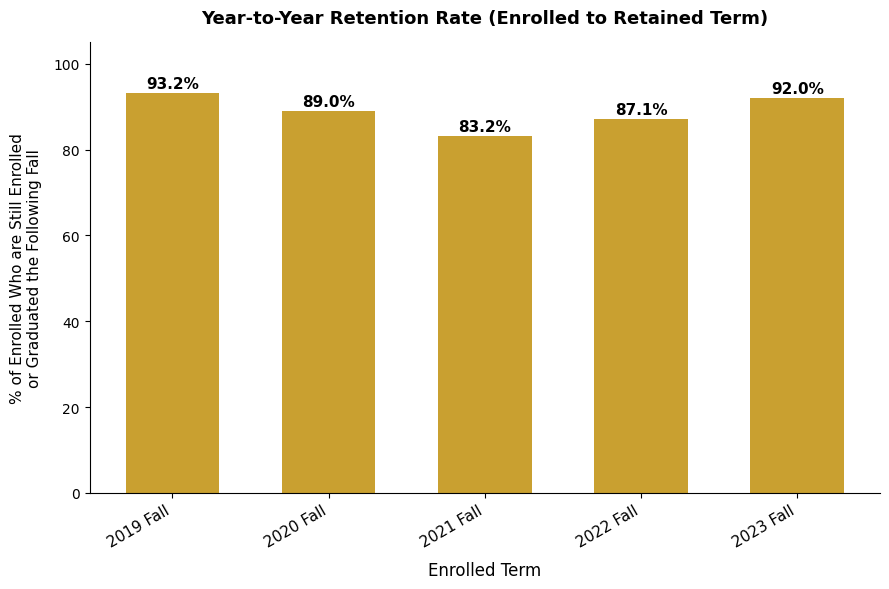

Chart saved -> SES_PHD_Retention_Chart.png


In [5]:
fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(summary['Base.Term'], summary['pct'],
              color=GOLD, width=0.6, edgecolor='none')

# Percentage labels above each bar
for bar, pct in zip(bars, summary['pct']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{pct}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Year-to-Year Retention Rate (Enrolled to Retained Term)',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Enrolled Term', fontsize=12, labelpad=8)
ax.set_ylabel('% of Enrolled Who are Still Enrolled\nor Graduated the Following Fall',
              fontsize=11, labelpad=8)
ax.set_ylim(0, 105)
ax.set_xticks(range(len(summary)))
ax.set_xticklabels(summary['Base.Term'], rotation=30, ha='right', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.savefig(CHART_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved -> {CHART_PATH}')


---
## 5. Chi-Square Test of Independence

Tests whether retention rates differ significantly across any pair of years.
Uses a 5×2 contingency table (year × retained/not retained).


In [6]:
contingency = summary[['retained', 'not_retained']].values  # shape: (5, 2)

chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency, correction=False)

print('=== Chi-square Test of Independence ===')
print(f'  Chi2 statistic     : {chi2:.4f}')
print(f'  Degrees of freedom : {dof}')
print(f'  P-value            : {p_chi2:.4f}')
print()
if p_chi2 < ALPHA:
    print(f'  SIGNIFICANT (p < {ALPHA}): at least one pair of years differs in retention rate.')
    print('  -> Proceeding to pairwise comparisons.')
else:
    print(f'  Not significant (p >= {ALPHA}): no evidence of year-to-year differences.')


=== Chi-square Test of Independence ===
  Chi2 statistic     : 14.3129
  Degrees of freedom : 4
  P-value            : 0.0064

  SIGNIFICANT (p < 0.05): at least one pair of years differs in retention rate.
  -> Proceeding to pairwise comparisons.


---
## 6. Pairwise Two-Proportion Z-Tests (Bonferroni Correction)

Compares every pair of enrolled terms using a two-proportion z-test.
P-values are Bonferroni-corrected for the number of comparisons.


In [7]:
def two_prop_z(r1, n1, r2, n2):
    """Two-proportion z-test (pooled SE). Returns (z_statistic, two_tailed_p)."""
    p1     = r1 / n1
    p2     = r2 / n2
    p_pool = (r1 + r2) / (n1 + n2)
    se     = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
    z      = (p1 - p2) / se
    p      = 2 * (1 - stats.norm.cdf(abs(z)))
    return z, p


pairs   = list(combinations(range(len(terms)), 2))
n_pairs = len(pairs)

pw_rows = []
for i, j in pairs:
    ri, ni = int(summary.iloc[i]['retained']), int(summary.iloc[i]['total'])
    rj, nj = int(summary.iloc[j]['retained']), int(summary.iloc[j]['total'])
    z, p   = two_prop_z(ri, ni, rj, nj)
    p_bon  = min(p * n_pairs, 1.0)
    delta  = round(summary.iloc[j]['pct'] - summary.iloc[i]['pct'], 1)
    pw_rows.append({
        'Enrolled Term 1'     : terms[i],
        'Enrolled Term 2'     : terms[j],
        'Z-Statistic'         : round(z, 4),
        'P-Value'             : round(p, 4),
        'P-Value (Bonferroni)': round(p_bon, 4),
        'Delta (%)'           : f'{delta:+.1f}%',
        'Significant'         : 'Yes' if p_bon < ALPHA else '',
    })

pw_df = pd.DataFrame(pw_rows)
pw_df


,Enrolled Term 1,Enrolled Term 2,Z-Statistic,P-Value,P-Value (Bonferroni),Delta (%),Significant
0,2019 Fall,2020 Fall,1.5333,0.1252,1.0000,-4.2%,
1,2019 Fall,2021 Fall,3.2363,0.0012,0.0121,-10.0%,Yes
2,2019 Fall,2022 Fall,2.0896,0.0367,0.3665,-6.1%,
3,2019 Fall,2023 Fall,0.4909,0.6235,1.0000,-1.2%,
4,2020 Fall,2021 Fall,1.7804,0.0750,0.7502,-5.8%,
5,2020 Fall,2022 Fall,0.5899,0.5552,1.0000,-1.9%,
6,2020 Fall,2023 Fall,-1.0556,0.2912,1.0000,+3.0%,
7,2021 Fall,2022 Fall,-1.1697,0.2421,1.0000,+3.9%,
8,2021 Fall,2023 Fall,-2.7978,0.0051,0.0515,+8.8%,
9,2022 Fall,2023 Fall,-1.6261,0.1039,1.0000,+4.9%,


---
## 7. Significant Findings

In [8]:
sig = pw_df[pw_df['Significant'] == 'Yes'].copy()

if sig.empty:
    print('No pairwise comparisons survived Bonferroni correction.')
else:
    print('Statistically significant differences (Bonferroni-corrected):\n')
    for _, r in sig.iterrows():
        print(f"  {r['Enrolled Term 1']} vs {r['Enrolled Term 2']}")
        print(f"    Z = {r['Z-Statistic']},  p(Bonferroni) = {r['P-Value (Bonferroni)']},  delta = {r['Delta (%)']}")
        print()


Statistically significant differences (Bonferroni-corrected):

  2019 Fall vs 2021 Fall
    Z = 3.2363,  p(Bonferroni) = 0.0121,  delta = -10.0%



---
## Conclusion

A statistically significant decrease in retention rates (**-20.0%**) was found between the **2019 Fall** Enrolled Term and the **2021 Fall** Enrolled Term for PhD students in SES.

Changes in retention rates when comparing all other year pairs were **not** statistically significant — differences observed were consistent with normal year-to-year variation.
